In [11]:
import pandas as pd
import numpy as np
import matplotlib.gridspec as gridspec
from sklearn.manifold import TSNE, trustworthiness
import umap
import time
import somJ.config as config
from functions import *
from somJ.som import SoM
from sklearn.neighbors import NearestNeighbors
import gc
import warnings
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [ ]:
def apply_umap(X):
    reducer = umap.UMAP(n_components=2, random_state=42)
    return reducer.fit_transform(X) 

def apply_tsne(X):
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    return tsne.fit_transform(X)

# Devuleve las muestras como las coordenadas del nodo ganador
def apply_som_j(X_scaled):
    som = SoM(
            method=config.INIT_METHOD,
            data=X_scaled[:1000],
            total_nodes=config.TOTAL_NODES
        )
    som.train(
            train_data=X_scaled
        )
    pos=np.array([som.find_winner(x) for x in X_scaled])
    (m, n)=som.grid_size
    return pos,m,n


def evaluate_embedding(X, X_embedded, n_neighbors=5):
    trust = trustworthiness(X, X_embedded, n_neighbors=n_neighbors)
    cont = compute_continuity(X, X_embedded, n_neighbors=n_neighbors)
    return trust, cont

def compute_som_histogram(positions, labels):
    #Convierte el SOM winner positions into a histogram (dict) per neuron position.
    som_grid = {}
    for pos, label in zip(positions, labels):
        pos_tuple = tuple(pos)
        if pos_tuple not in som_grid:
            som_grid[pos_tuple] = {}
        som_grid[pos_tuple][label] = som_grid[pos_tuple].get(label, 0) + 1
    return som_grid

# Representar mapas en 2D 
def plot_embedding(X, y, method_name, dataset_name,m_neurons =0,n_neurons=0):
    if method_name == "SOM":
        if not isinstance(X, dict):
            raise TypeError(f"Expected dict for SOM, got {type(X)}")

        label_names = np.unique(y)
        fig = plt.figure(figsize=(10, 10))
        the_grid = gridspec.GridSpec(n_neurons, m_neurons, fig)

        for position in X:
            label_fracs = [X[position].get(label, 0) for label in label_names]
            ax = plt.subplot(the_grid[n_neurons - 1 - position[1], position[0]], aspect=1)
            patches, _ = ax.pie(label_fracs, colors=plt.cm.tab10.colors, radius=1)

        plt.tight_layout()
        plt.savefig(f'experimentos/g_top/{method_name}_{dataset_name}_pie.png', dpi=300)

    else:
        plt.figure(figsize=(10, 8))
        unique_labels = np.unique(y)
        markers = ['o', 's', '^', 'P', '*', 'X', 'D', 'v', '<', '>']
        colors = sns.color_palette('tab10', len(unique_labels))

        for idx, label in enumerate(unique_labels):
            indices = np.where(y == label)
            plt.scatter(X[indices, 0], X[indices, 1], label=f'Clase {label}',
                        marker=markers[idx % len(markers)], color=colors[idx],
                        s=50, alpha=0.7, edgecolors='w')

        plt.legend(title='Clases', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.title(f'{method_name} - {dataset_name}')
        plt.xlabel('Dimensión 1')
        plt.ylabel('Dimensión 2')
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(f'experimentos/g_top/{method_name}_{dataset_name}.png', dpi=300)


In [13]:
def evaluate_all(datasets, eval_subset_size=5000, n_neighbors=5, random_state=42, n_splits=5):
    all_results = []

    for name in datasets:
        print(f"\nDataset: {name}")
        X, y = load_dataset(name)
        n_samples = len(X)

        # Reducir tamaño para speed si es muy grande
        if n_samples > eval_subset_size:
            np.random.seed(random_state)
            idx_total = np.random.choice(n_samples, eval_subset_size, replace=False)
            X = X[idx_total]
            y = y[idx_total]

        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

        # Para acumular métricas por pliegue
        fold_metrics = { "UMAP": [], "t-SNE": [], "SOM": [] }
        fold_times   = { "UMAP": [], "t-SNE": [], "SOM": [] }

        for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
            print(f" Fold {fold}/{n_splits}")
            X_train, y_train = X[train_idx], y[train_idx]
            X_test,  y_test  = X[test_idx],  y[test_idx]

            # --- UMAP ---
            start = time.perf_counter()
            umap_reducer = umap.UMAP(n_components=2, random_state=random_state)
            X_train_umap = umap_reducer.fit_transform(X_train)
            X_test_umap  = umap_reducer.transform(X_test)
            t_umap = time.perf_counter() - start

            # --- t-SNE (no tiene transform, ajustamos sobre todo el fold) ---
            start = time.perf_counter()
            tsne = TSNE(n_components=2, random_state=random_state, perplexity=30)
            X_fold = np.vstack([X_train, X_test])
            X_fold_tsne = tsne.fit_transform(X_fold)
            X_train_tsne = X_fold_tsne[:len(train_idx)]
            X_test_tsne  = X_fold_tsne[len(train_idx):]
            t_tsne = time.perf_counter() - start

            # --- SOM ---
            start = time.perf_counter()
            som = SoM(method=config.INIT_METHOD,
                      data=X_train[:1000],
                      total_nodes=config.TOTAL_NODES)
            som.train(train_data=X_train,batch_size=5000)
            pos_train = np.array([som.find_winner(x) for x in X_train])
            pos_test  = np.array([som.find_winner(x) for x in X_test])
            m, n = som.grid_size
            t_som = time.perf_counter() - start

            # Evaluar embedings en el conjunto de test
            for method, X_emb, t_exec in [
                ("UMAP", np.vstack([X_train_umap, X_test_umap]),    t_umap),
                ("t-SNE", np.vstack([X_train_tsne, X_test_tsne]),  t_tsne),
                ("SOM", np.vstack([pos_train, pos_test]),          t_som),
            ]:
                trust, cont = evaluate_embedding(
                    np.vstack([X_train, X_test]),
                    X_emb,
                    n_neighbors=n_neighbors
                )
                fold_metrics[method].append((trust, cont))
                fold_times[method].append(t_exec)

        # Tras los 5 folds, promediar y guardar
        for method in ["UMAP", "t-SNE", "SOM"]:
            trusts, conts = zip(*fold_metrics[method])
            all_results.append({
                "Dataset": name,
                "Método": method,
                "Trustworthiness": round(np.mean(trusts), 3),
                "Continuity":       round(np.mean(conts), 3),
                "Time":             round(np.mean(fold_times[method]), 3)
            })

    df = pd.DataFrame(all_results)
    return df


In [14]:
datasets = [
            'Iris', 
            'Digits', 
            'MNIST', 'Fashion MNIST']

df_results = evaluate_all(datasets)


Dataset: Iris
 Fold 1/5
 Fold 2/5
 Fold 3/5
 Fold 4/5
 Fold 5/5

Dataset: Digits
 Fold 1/5
 Fold 2/5
 Fold 3/5
 Fold 4/5
 Fold 5/5

Dataset: MNIST
 Fold 1/5
 Fold 2/5
 Fold 3/5
 Fold 4/5
 Fold 5/5

Dataset: Fashion MNIST
 Fold 1/5
 Fold 2/5
 Fold 3/5
 Fold 4/5
 Fold 5/5


In [15]:

print("\n Resultados por Dataset y Método:")
print(df_results)

# Guardar también los promedios
df_results.to_csv("resultados_topologia.csv", index=False)

print("\n Resultadosguardados como CSV")


# Graficos -------------------------------------------------------------------------




 Resultados por Dataset y Método:
          Dataset Método  Trustworthiness  Continuity    Time
0            Iris   UMAP            0.975       0.562   0.148
1            Iris  t-SNE            0.990       0.713   0.280
2            Iris    SOM            0.427       0.044   0.030
3          Digits   UMAP            0.987       0.363   1.987
4          Digits  t-SNE            0.995       0.588   2.952
5          Digits    SOM            0.924       0.098   0.449
6           MNIST   UMAP            0.958       0.219  11.629
7           MNIST  t-SNE            0.988       0.481   8.641
8           MNIST    SOM            0.855       0.034   7.899
9   Fashion MNIST   UMAP            0.979       0.224  11.818
10  Fashion MNIST  t-SNE            0.991       0.448   9.964
11  Fashion MNIST    SOM            0.709       0.008   8.285

 Resultadosguardados como CSV


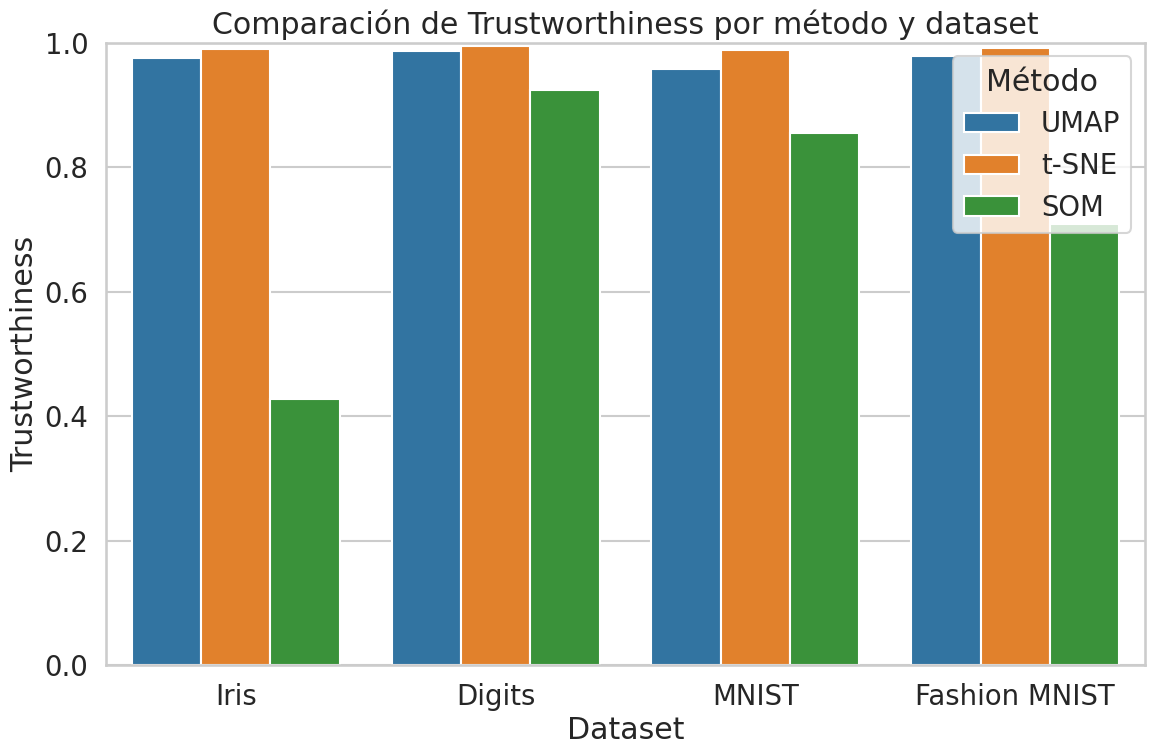

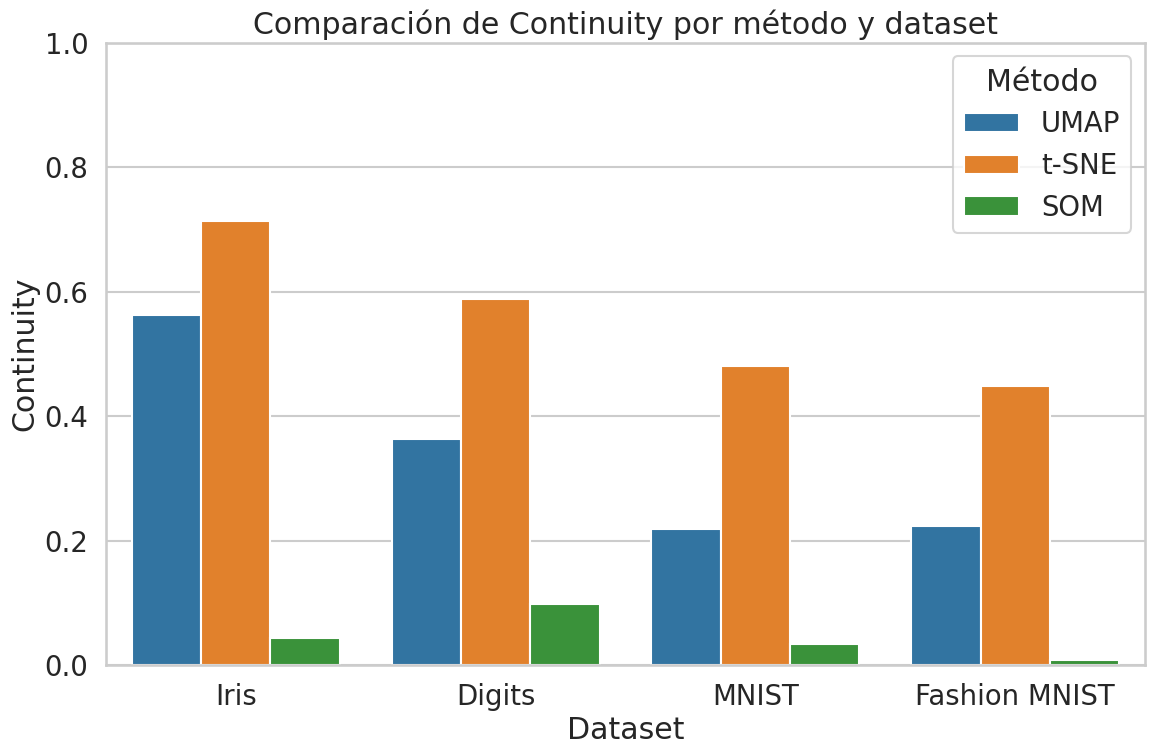

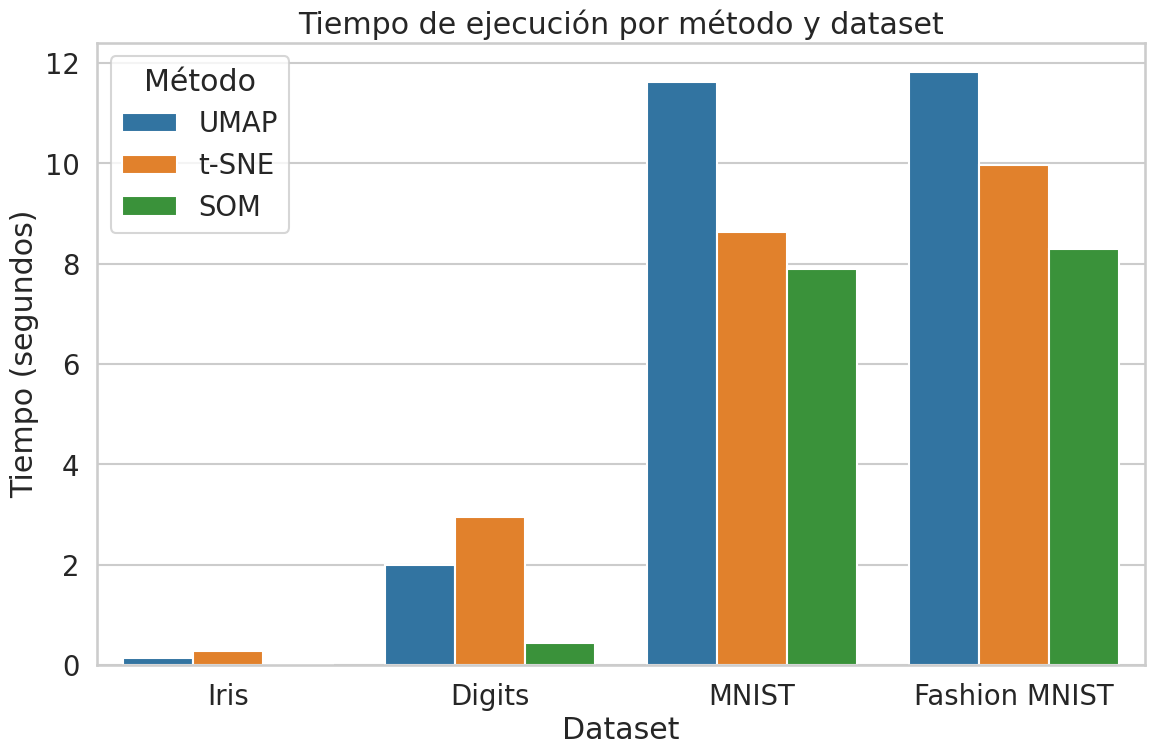

In [17]:
sns.set_context("talk", font_scale=1.2)
sns.set_style("whitegrid")

# Ejecutar la evaluación previamente definida

# Trustworthiness
plt.figure(figsize=(12, 8))
sns.barplot(data=df_results, x="Dataset", y="Trustworthiness", hue="Método")
plt.title('Comparación de Trustworthiness por método y dataset')
plt.ylim(0, 1)
plt.ylabel('Trustworthiness')
plt.xlabel('Dataset')
plt.legend(title='Método', loc='upper right')
plt.tight_layout()
plt.savefig('g_top/trustworthiness_comparacion.png', dpi=300)

# Continuity
plt.figure(figsize=(12, 8))
sns.barplot(data=df_results, x="Dataset", y="Continuity", hue="Método")
plt.title('Comparación de Continuity por método y dataset')
plt.ylim(0, 1)
plt.ylabel('Continuity')
plt.xlabel('Dataset')
plt.legend(title='Método', loc='upper right')
plt.tight_layout()
plt.savefig('g_top/continuity_comparacion.png', dpi=300)

# Tiempo de ejecución
plt.figure(figsize=(12, 8))
sns.barplot(data=df_results, x="Dataset", y="Time", hue="Método")
plt.title('Tiempo de ejecución por método y dataset')
plt.ylabel('Tiempo (segundos)')
plt.xlabel('Dataset')
plt.legend(title='Método', loc='upper left')
plt.tight_layout()
plt.savefig('g_top/tiempo_ejecucion_comparacion.png', dpi=300)
